# Advanced Chemical Reaction Engineering (CBE 60546)
## Homework 6
## Due October 29, 2025

Carefully and neatly document your answers. Use Jupyter/Collab for all plots. See sample code at https://github.com/wmfschneider/CBE60546/blob/main/Resources/Examples.ipynb.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import fsolve

# Q1. Looking only at the surface
One method of determining the surface area of Pt catalysts is by surface titration with $\ce{H2}$. $\ce{H2}$ is thought to adsorb dissociatively, one H atom per surface Pt:

$\ce{H2 + 2* <=> 2 H*}$

### Q1.1. Derive the Langmuir isotherm for dissociative adsorption of $\ce{H2}$.

If the adsorption process is at **equilibrium**, the adsorption and desorption rates are equal:
$r_{\text{ads}} = r_{\text{des}}$

$k_{\text{ads}} P_{H_2} N^2 \theta_*^2 = k_{\text{des}} N^2 \theta_{H}^2$

where  
- $P_{H_2}$: partial pressure of $H_2$
- $N\ $: total number of active sites  
- $\theta_*$: fraction of empty sites  
- $\theta_{H}$: fraction of occupied sites  

and we know site balance: $1 = \theta_* + \theta_{H}$

---

### Define the equilibrium constant
$K = \frac{k_{\text{ads}}}{k_{\text{des}}} = \frac{\theta_H^2}{P_{H_2} \, \theta_*^2}$

Rearranging:
$\theta_H^2 = K P_{H_2} \, \theta_*^2$

Substitute $\theta_* = 1 - \theta_H$ and rearange for $\theta_H$

$\boxed{\theta_H = \frac{\sqrt{K P_{H_2}}}{1 + \sqrt{K P_{H_2}}}}$

### Q1.2. The data below were obtained for isothermal $\ce{H2}$ chemisorption on a 3% (w/w) Pt catalyst supported on γ-alumina (nominally $\ce{Al2O3}$). Does the data conform to a dissociative Langmuir adsorption model?

| Pressure (bar) | mass $\ce{H2}$/catalyst (${\mu}$g g$^{-1}$)  |
|----------------|----------------------------------------------------|
|     0.0759     |                        1.30                        |
|     0.152      |                        1.82                        |
|     0.228      |                        2.30                        |
|     0.304      |                        2.44                        |
|     0.378      |                        2.55                        |
|     1.518      |                        4.51                        |
|     1.896      |                        4.59                        |
|     2.276      |                        4.95                        |
|     2.662      |                        5.21                        |
|     3.035      |                        5.35                        |
|     3.408      |                        5.50                        |
|     3.781      |                        5.65                        |


In [1]:
data1 = np.array([[0.0759, 1.30],
    [0.152, 1.82],
    [0.228, 2.30],
    [0.304, 2.44],
    [0.378, 2.55],
    [1.518, 4.51],
    [1.896, 4.59],
    [2.276, 4.95],
    [2.662, 5.21],
    [3.035, 5.35],
    [3.408, 5.50],
    [3.781, 5.65]])
data1 = data1.transpose()
P = data1[0]
H = data1[1]

NameError: name 'np' is not defined

  H_max = 11.913 μg/g
  K     = 0.2199 bar^-1
  RMSE  = 0.0739
  R^2   = 0.9977


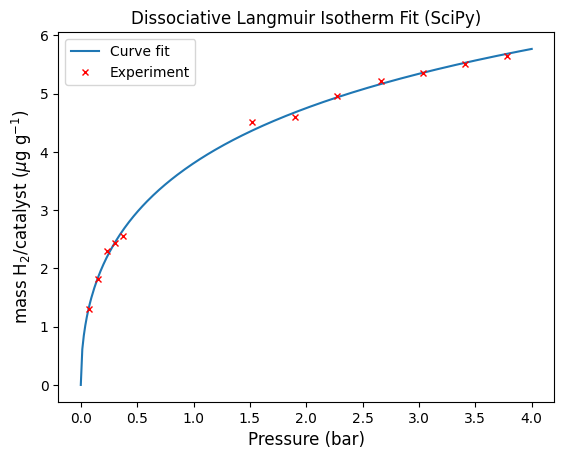

In [3]:
def theta_H(P, Hmax, K):
    return Hmax * np.sqrt(K * P) / (1 + np.sqrt(K * P))

initial_guess = [10, 0.1]  # [Hmax, K]
params, cov = curve_fit(theta_H, P, H, p0=initial_guess, bounds=(0, np.inf))
Hmax_pred, K_pred = params
H_pred = theta_H(P,Hmax_pred, K_pred)

rmse = np.sqrt(np.mean((H - H_pred)**2))
r2 = 1 - np.sum((H - H_pred)**2) / np.sum((H - np.mean(H))**2)

print(f"  H_max = {Hmax_pred:.3f} μg/g")
print(f"  K     = {K_pred:.4f} bar^-1")
print(f"  RMSE  = {rmse:.4f}")
print(f"  R^2   = {r2:.4f}")

P_grid = np.linspace(0, 4, 300)
H_curve = theta_H(P_grid, Hmax_pred, K_pred)
plt.plot(P_grid, H_curve, label='Curve fit')

plt.plot(P, H, 'rx', markersize=5, label='Experiment')
plt.xlabel('Pressure (bar)', fontsize=12)
plt.ylabel(r'mass $\mathrm{H_2}$/catalyst ($\mu$g g$^{-1}$)', fontsize=12)
plt.title('Dissociative Langmuir Isotherm Fit (SciPy)')
plt.legend()
plt.show()

### Q1.3. What is the dispersion of the Pt particles (fraction of atoms accessible to $\ce{H2}$)?

1) Convert uptake to moles of H₂ per gram of catalyst:
$$
n_{\mathrm{H_2}}=\frac{11.9\times10^{-6}\ \mathrm{g}}{2.016\ \mathrm{g\ mol^{-1}}}
= 5.90\times10^{-6}\ \mathrm{mol\ H_2\ g^{-1}}
$$

2) Each $H_2 \rightarrow$ **2 H\*** $\rightarrow$ **2 surface Pt atoms**:
$$
n_{\mathrm{Pt,surf}} = 2\,n_{\mathrm{H_2}}
= 1.18\times10^{-5}\ \mathrm{mol\ Pt_{surf}\ g^{-1}}
$$

3) Total Pt per gram of catalyst:
$$
n_{\mathrm{Pt,tot}}=
\frac{0.03\ \mathrm{g}}{195.08\ \mathrm{g\ mol^{-1}}}
=1.54\times10^{-4}\ \mathrm{mol\ Pt\ g^{-1}}
$$

4) **Dispersion** (fraction of Pt atoms accessible):
$$
\boxed{D=\frac{n_{\mathrm{Pt,surf}}}{n_{\mathrm{Pt,tot}}}
= \frac{1.18\times10^{-5}}{1.54\times10^{-4}}
\approx 0.08\ \text{(8\%)} }
$$

### Q1.4. What is the mean diameter of the Pt particles, assuming they are spheres?

We estimate diameter \(d\) by equating the **fraction of surface atoms** to the **surface-to-volume atom ratio** of a spherical particle:

$
D \;\approx\; \frac{N_{\text{surf}}}{N_{\text{tot}}}
= \frac{A\,n_s}{V\,n_v}
$

For a sphere of diameter \(d\):
$
A = \pi d^2,\qquad V = \frac{\pi d^3}{6}
$
Therefore
$
\frac{A}{V} = \frac{\pi d^2}{(\pi d^3/6)} = \frac{6}{d}.
$
Plugging $A/V = 6/d$ into $D = (A n_s)/(V n_v)$ gives
$
\boxed{ D = \frac{6\,n_s}{n_v\,d} } \qquad \Rightarrow \qquad
\boxed{ d = \frac{6\,n_s}{n_v\,D} }.
$

### Numbers for Pt (to get a practical constant)
- fcc lattice parameter $(a=3.924\ \text{Å})$  
- Close-packed (111) surface atom density  
  $
  n_s = \frac{2}{\sqrt{3}a^2}
      \approx 7.5\times10^{18}\ \text{atoms m}^{-2}
  $
- Bulk atomic density from $(\rho=21.45\ \text{g cm}^{-3})$, $(M=195.08\ \text{g mol}^{-1})$:
  $
  n_v = \frac{N_A\,\rho}{M}
      \approx 6.62\times10^{28}\ \text{atoms m}^{-3}
  $

Hence
$
\frac{6\,n_s}{n_v} = 
\frac{6\times 7.5\times10^{18}}{6.62\times10^{28}}
= 6.8\times10^{-10}\ \text{m}
= 0.68\ \text{nm}.
$

**Using $D\approx 0.08$:**
$
\boxed{ d_{\text{nm}} \approx \frac{0.68}{0.08} \approx 8.5\ \text{nm} }.
$

# Q2. Langmuir, Hinshelwood, and company
Bob Davis and students (https://doi.org/10.1006/jcat.1999.2780) studied the reduction of nitrous oxide by carbon monoxide over a ceria-supported Rh catalyst. Following are rate data obtained at 543 K.

| $P_{\ce{CO}}$ (torr) | $P_{\ce{N2O}}$ (torr) | TOF (s$^{-1}$) |
|----------------------|-----------------------|------------------------|
|         30.4         |          7.6          |         0.005          |
|         30.4         |         15.2          |         0.0091         |
|         30.4         |         30.4          |         0.018          |
|         30.4         |         45.6          |         0.023          |
|         30.4         |          76           |         0.036          |
|         7.6          |         30.4          |         0.039          |
|         15.2         |         30.4          |         0.024          |
|         45.6         |         30.4          |         0.012          |
|          76          |         30.4          |         0.0078         |

### Q2.1. What is the apparent rate order with respect to $\ce{CO}$? With respect to $\ce{N2O}$?

In [4]:
data2 = np.array([[30.4, 7.6, 0.005],
    [30.4, 15.2, 0.0091],
    [30.4, 30.4, 0.018],
    [30.4, 45.6, 0.023],
    [30.4, 76, 0.036],
    [7.6, 30.4, 0.039],
    [15.2, 30.4, 0.024],
    [45.6, 30.4, 0.012],
    [76, 30.4, 0.0078]])
data2 = data2.transpose()
# N2O order at fixed P_CO = 30.4 torr
P_N2O = data2[1][0:5]
TOF_at_CO30 = data2[2][0:5]

# CO order at fixed P_N2O = 30.4 torr
P_CO = data2[0][5:10]
TOF_at_N2O30 = data2[2][5:10]

# log–log slopes = apparent orders
m_N2O, _ = np.polyfit(np.log(P_N2O), np.log(TOF_at_CO30), 1)
m_CO, _   = np.polyfit(np.log(P_CO),   np.log(TOF_at_N2O30), 1)

print(f"Apparent order in N2O: {m_N2O:.2f}")
print(f"Apparent order in CO : {m_CO:.2f}")

Apparent order in N2O: 0.86
Apparent order in CO : -0.69


### Q2.2. Following is a candidate mechanism. Derive a Langmuir-Hinshelwood rate expression assuming the first two reactions are quasi-equilibrated and the third reaction is rate-limiting.

$\ce{N2O + \ast{} <=>[k_1][k_{-1}] N2O^\ast}$ \
$\ce{CO + \ast{} <=>[k_2][k_{-2}] CO^\ast}$ \
$\ce{N2O^\ast{} ->[k_3] N2 + O^\ast}$ \
$\ce{CO^\ast{} + O^\ast{} ->[k_4] CO2 }$

**Mechanism**
$
\begin{aligned}
\ce{N2O + * &<=> N2O*} &&K_1=\dfrac{\theta_{\mathrm{N2O*}}}{P_{\mathrm{N2O}}\theta_*} \\
\ce{CO + *  &<=> CO* } &&K_2=\dfrac{\theta_{\mathrm{CO*}}}{P_{\mathrm{CO}}\theta_*} \\
\ce{N2O*    &-> N2 + O*} &&\text{rate-limiting } (k_3)\\
\ce{CO* + O*&-> CO2 + *} &&\text{fast}
\end{aligned}
$

Assuming the last step is fast, oxygen does **not** accumulate:$ \theta_{\mathrm{O*}}\approx 0 . $

**Site balance**
$
\theta_*+\theta_{\mathrm{N2O*}}+\theta_{\mathrm{CO*}}\approx 1 .
$

From the equilibria:
$
\theta_{\mathrm{N2O*}}=K_1 P_{\mathrm{N2O}}\theta_*,\qquad
\theta_{\mathrm{CO*}} =K_2 P_{\mathrm{CO}}\theta_* .
$

Insert into the site balance:
$
\theta_*\!\left(1+K_1P_{\mathrm{N2O}}+K_2P_{\mathrm{CO}}\right)=1
\;\Rightarrow\;
\theta_*=\frac{1}{1+K_1P_{\mathrm{N2O}}+K_2P_{\mathrm{CO}}}.
$

**Rate:**
$r_{overall} = r_{3} = k_3\,\theta_{\mathrm{N2O*}}
  = k_3\,K_1 P_{\mathrm{N2O}}\,\theta_*
  = \boxed{\,\frac{k_3 K_1 P_{\mathrm{N2O}}}
                {1+K_1P_{\mathrm{N2O}}+K_2P_{\mathrm{CO}}}\, }.$

**Limiting apparent orders**
- Low pressures: $r \approx k_3 K_1 P_{\mathrm{N2O}}$→ first order in $N_2O$, zero in CO.
- High CO: $r \approx (k_3 K_1/K_2)\,(P_{\mathrm{N2O}}/P_{\mathrm{CO}})$ → ~first in $N_2O$, **negative first** in CO.

### Q2.3. Use the observed data and regression to estimate the rate parameters. (*Hint*: Linearize to estimate the rate parameters, and use these as guesses for non-linear regression.)

### Linearization of the Langmuir–Hinshelwood rate expression

We start from the derived rate law (step 3 rate-limiting, steps 1–2 quasi-equilibrated):

$$ r = \frac{k_3 K_1 P_{\mathrm{N_2O}}}{1 + K_1 P_{\mathrm{N_2O}} + K_2 P_{\mathrm{CO}}} $$
We know the experimental values of $r, P_{\mathrm{N_2O}}, and P_{\mathrm{CO}}.$  
We need to estimate the unknown kinetic parameters $k_3, K_1, and K_2.$

---

#### Step 1 — Invert the rate expression

$$ \frac{1}{r} = \frac{1 + K_1 P_{\mathrm{N_2O}} + K_2 P_{\mathrm{CO}}}{k_3 K_1 P_{\mathrm{N_2O}}} $$

---

#### Step 2 — Multiply both sides by $P_{\mathrm{N_2O}}$

$$
\frac{P_{\mathrm{N_2O}}}{r}
= \frac{1}{k_3 K_1}
+ \frac{P_{\mathrm{N_2O}}}{k_3}
+ \frac{K_2 P_{\mathrm{CO}}}{k_3 K_1}
$$

---

#### Step 3 — Identify linear regression form

Let
$
y = \frac{P_{\mathrm{N_2O}}}{r}, \qquad
X_1 = P_{\mathrm{N_2O}}, \qquad
X_2 = P_{\mathrm{CO}}
$

Then

$
y
= A + B X_1 + C X_2
$

where

$
A = \frac{1}{k_3 K_1}, \qquad
B = \frac{1}{k_3}, \qquad
C = \frac{K_2}{k_3 K_1}
$

Parameters \(A\), \(B\), and \(C\) can be obtained via **linear least-squares regression**.

In [5]:
# Data (543 K)
P_CO  = data2[0]   # torr
P_N2O = data2[1]   # torr
r_obs = data2[2]  # s^-1 (TOF)

y = P_N2O / r_obs
X = np.column_stack([np.ones_like(P_CO), P_N2O, P_CO])  # columns: [1, Pn, Pc]
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
A, B, C = beta

k3_init = 1.0 / B
K1_init = B / A
K2_init = C / A
print(f"  k3  ≈ {k3_init:.4f} s^-1")
print(f"  K1  ≈ {K1_init:.4f} torr^-1")
print(f"  K2  ≈ {K2_init:.4f} torr^-1")

  k3  ≈ 0.1213 s^-1
  K1  ≈ 0.0453 torr^-1
  K2  ≈ 0.2479 torr^-1


### Q2.4. What is the most abundant surface species, $CO or NO_{2}$, under the experimental conditions?

From the Langmuir–Hinshelwood mechanism, the quasi-equilibrated adsorption steps give

$$
\theta_{\mathrm{N_2O^*}}
= \frac{K_1 P_{\mathrm{N_2O}}}{1 + K_1 P_{\mathrm{N_2O}} + K_2 P_{\mathrm{CO}}}, 
\qquad
\theta_{\mathrm{CO^*}}
= \frac{K_2 P_{\mathrm{CO}}}{1 + K_1 P_{\mathrm{N_2O}} + K_2 P_{\mathrm{CO}}}
$$
$$
\frac{\theta_{\mathrm{N_2O^*}}}{\theta_{\mathrm{CO^*}}} = \frac{K_1 P_{\mathrm{N_2O}}}{K_2 P_{\mathrm{CO}}}
$$

Experimentally, we determined
$
K_2 P_{\mathrm{CO}} \gg K_1 P_{\mathrm{N_2O}}
$

Therefore,
$
\theta_{\mathrm{CO^*}} \gg \theta_{\mathrm{N_2O^*}}
$

# Q3.Peak performance
Ammonia synthesis ($\ce{N2 + 3 H2 <=> 2 NH3}$) is among the most important heterogeneous catalytic reactions and has been studied extensively. Mehta (https://doi.org/10.1021/acscatal.0c00684) following Grabow write a simple lumped model for the mechanism over a metal catalyst:

| |        $E_a$ (eV)       | $\Delta S^{\circ\ddagger}$ (J/mol K)  | $\Delta E$ (eV) | $\Delta S^\circ$ (J/mol K)|
|-|--------------------|-----------------------------|-------------|------------------|
| $\ce{N2 + 2\ast{} <=> 2 N^\ast{} }$       | $1.57 E_N + 1.56$  |          $-216.9$           |   $2 E_N$   |     $-216.9$     |
| $\ce{N^\ast{} + 3/2 H2 <=> NH3 + \ast{}}$ | $-0.39 E_N + 1.24$ |           $-5.6$            | $-0.55-E_N$ |      $-5.6$     

The activation energies for both steps are related through a Bronsted-Evans-Polanyi relationship to the binding energy of $\ce{N}$, $E_N$. Those relationships are shown above, along with  entropy data at 1 bar standard state. Note $k_B$ = 8.6173$\times$10$^{-5}$ eV/K.

### Q3.1. Determine and plot the log $\ce{NH3}$ synthesis rate per site (turnover frequency) at 700 K, 100 bar, and a stoichiometric mixture of $\ce{N2}$ and $\ce{H2}$ at 1% conversion, as a function of $E_N$ from -1.3 to 0 eV.  (*Hint*: Relate $\theta_N$ and $\theta^*$ through a site balance and $d\theta/dt$ to find the steady-state coverages. Back solve for the net rate of reaction at steady-state.)

In [6]:
# Constants
R = 8.314462618             # J/mol/K
h = 6.62607015e-34          # J*s
kB_J = 1.380649e-23         # J/K
eV_to_kJmol = 96.485        # kJ/mol per eV

# Given in the problem statement
T = 700.0                   # K
P_tot = 100.0               # bar
y_N2, y_H2 = 0.25, 0.75     # stoichiometric mixture
P0 = 1.0                    # bar
P_N2 = y_N2 * P_tot
P_H2 = y_H2 * P_tot
P_NH3 = 0 # Initially there's no ammonia

def rate_constants(EN):
    # -----------Define Energies-------------
    # Reaction 1
    # Forward
    Ea1f = 1.57*EN+1.56
    dS1f = -216.9
    # Backward
    Ea1b = Ea1f - 2*EN # Ea-dE = Eaf-dE
    dS1b = dS1f - (-216.9) # dS_TS-dS_rxn = dSf - dS_rxn
    
    # Reaction 2
    # Forward
    Ea2f = -0.39*EN+1.24
    dS2f = -5.6
    # Backward
    Ea2b = Ea2f - (-0.55-EN)
    dS2b = dS2f - (-5.6)
    
    # -----------Calculate rate constants-------------
    def k_TST(S,E):
        return kB_J*T/h*np.exp(S/R)*np.exp(-E*1e3*eV_to_kJmol/(R*T))
    k1f = k_TST(dS1f, Ea1f)
    k1b = k_TST(dS1b, Ea1b)
    k2f = k_TST(dS2f, Ea2f)
    k2b = k_TST(dS2b, Ea2b)
    return k1f, k1b, k2f, k2b

EN = -1 # eV
k1f, k1b, k2f, k2b = rate_constants(EN)
print(k1f, k1b, k2f, k2b) # /s

80.62127689184003 0.06864441342790678 13.676467183066293 46593.83453025812


For the two–step lumped ammonia synthesis mechanism, the site balance is

$\theta_* + \theta_N = 1$
and the steady–state condition on nitrogen coverage is

$
\frac{d\theta_N}{dt} = 0 = 2r_{1f} - 2r_{1b} - r_{2f} + r_{2b}
$
where 
$
r_{1f} = k_{1f} P_{\mathrm{N_2}} \theta_*^2,
\quad
r_{1b} = k_{1b} \theta_N^2,
\quad
r_{2f} = k_{2f} \theta_N P_{\mathrm{H_2}}^{3/2},
\quad
r_{2b}= k_{2b} P_{\mathrm{NH_3}} \theta_*
$

Substitute $\theta_* = 1 - \theta_N$:
$$
0 = 2k_{1f} P_{\mathrm{N_2}} (1 - \theta_N)^2 
- 2k_{1b} \theta_N^2
- k_{2f} \theta_N P_{\mathrm{H_2}}^{3/2}
+ k_{2b} P_{\mathrm{NH_3}}(1 - \theta_N)
$$

This nonlinear algebraic equation must be solved numerically for $\theta_N$ in the interval [0,1].

In Python, $\theta_N$ can be obtained using a root–finding method such as `scipy.optimize.root_scalar` or a custom secant method.

In [7]:
from scipy.optimize import fsolve
def steady_state_eq(theta_N, E_N, k1f, k1b, k2f, k2b):
    theta_star = 1.0 - theta_N
    r1 = k1f * P_N2 * theta_star**2 - k1b * theta_N**2
    r2 = k2f * theta_N * P_H2**1.5 - k2b * P_NH3 * theta_star
    return 2 * r1 - r2
theta0 = 0.5 # initial guess
theta = fsolve(steady_state_eq,theta0,args=(EN,k1f, k1b, k2f, k2b))[0]
print(f'the nitrogne coverate: {theta:.3f}')

the nitrogne coverate: 0.253


Now, solve for the rate of ammonia synthesis by back substituting to:
$$
r_{NH3} = r_{2,f}-r_{2,b} = k_{2f}*\theta_N*P_{H_2}^{1.5} - k_{2b}*P_{NH_3}*(1-\theta_N)
$$

In [8]:
r_NH3 = k2f*theta*P_H2**(3/2)-k2b*P_NH3*(1-theta)
print(f'rate of ammonia synthesis: {r_NH3:.3e}/s')

rate of ammonia synthesis: 2.249e+03/s


Text(0.5, 1.0, 'NH$_3$ synthesis: log TOF vs N binding energy (700 K, 100 bar)')

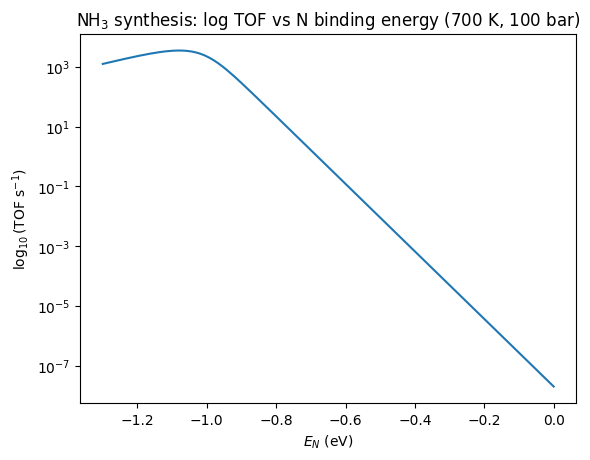

In [9]:
# ----------Calculate rates in a given range and plot-------------
EN_list = np.linspace(-1.3, 0.0, 200)
r_list = []
for EN in EN_list:
    k1f, k1b, k2f, k2b = rate_constants(EN)
    theta0 = 0.5
    theta = fsolve(steady_state_eq,theta0,args=(EN,k1f, k1b, k2f, k2b))[0]
    r_NH3 = k2f*theta*P_H2**(3/2)-k2b*P_NH3*(1-theta)
    r_list.append(r_NH3)
plt.plot(EN_list, r_list)
plt.yscale('log')
plt.xlabel(r'$E_N$ (eV)')
plt.ylabel(r'$\log_{10}(\mathrm{TOF}\ \mathrm{s}^{-1})$')
plt.title('NH$_3$ synthesis: log TOF vs N binding energy (700 K, 100 bar)')

### Q3.2. Typical catalysis Fe and Ru have N binding energies of $-1.2$ and $-0.5$ eV.  Can you see why these are useful catalysts?

From the log(TOF) vs. $E_N$ volcano-type plot in Q3.1, the $NH_3$ synthesis rate peaks at an **intermediate nitrogen binding energy**. This reflects the Sabatier principle (in lecture):

- If $E_N$ is **too negative** (very strong N binding), the surface becomes covered with N*, blocking sites → low rate.
- If $E_N$ is **too weak**, $N_2$ dissociation is slow → low rate.
- The **maximum rate occurs at moderate $E_N$** where $N_2$ activation is possible and the surface does not remain poisoned.

Fe and Ru sit near the volcano peak for $NH_3$ synthesis and achieve the best compromise between $N_2$ activation and product turnover, making them highly effective catalysts.